Polynomial Degree: 1
Training MSE: 42.90
Testing MSE: 42.99

Polynomial Degree: 2
Training MSE: 20.44
Testing MSE: 19.79

Polynomial Degree: 10
Training MSE: 18.26
Testing MSE: 38.42



<Figure size 1500x400 with 0 Axes>

<Figure size 1500x400 with 0 Axes>

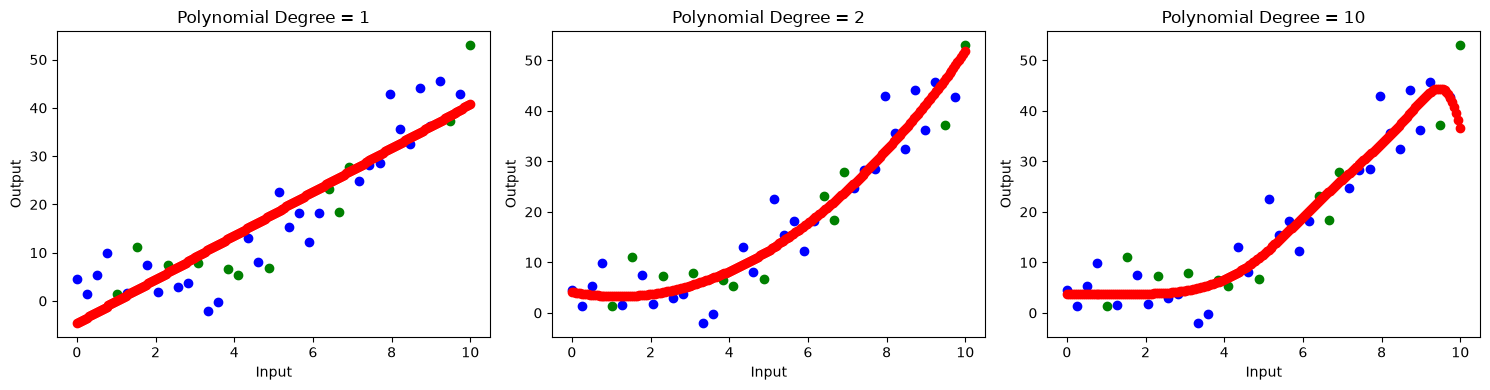

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

#Generate reprocuctible nonlinear data
np.random.seed(42)
#Generate 40 numbers between 0-10 with equal spacing
X=np.linspace(0,10,40).reshape(-1,1)

# np.random(0,5,40) is to generate random noise
# and add realistic variation to the output data
# np.random.normal(mean,standard_deviation,number_of_values)
y=2 + 0.5 * X[:,0] ** 2 + np.random.normal(0,5,40)

# Divide the data
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.30,random_state=42
)

degrees=[1,2,10]

# Include_bias=False is to tell the PolynomialFeatures not to create
# an additional constant column containing only 1s
for degree in degrees:

    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    model.fit(X_train,y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_prediction)
    test_mse = mean_squared_error(y_test,test_prediction)

    print(f"Polynomial Degree: {degree}")
    print(f"Training MSE: {train_mse:.2f}")
    print(f"Testing MSE: {test_mse:.2f}")
    print()

    X_plot = np.linspace(0,10,200).reshape(-1,1)

    plt.figure(figsize=(15,4))

for index, degree in enumerate(degrees):
    model = make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),
        LinearRegression()
    )
    model.fit(X_train,y_train)
    y_plot = model.predict(X_plot)

    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color="blue",label="Training Data")
    plt.scatter(X_test,y_test,color="green",label="Testing Data")
    plt.scatter(X_plot,y_plot,color="red",label="Prediction")

    plt.title(f"Polynomial Degree = {degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")

plt.tight_layout()
plt.show()



In [11]:
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

for degree in range(1,11):

    model=make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    scores = cross_val_score(
        model,X,y,cv=5,scoring="neg_mean_squared_error"
        # scikit-learn returns the negative value of the MSE
    )

    mean_mse = -scores.mean()
    print(f"Degree {degree}: cv MSE = {mean_mse:.2f}")


Degree 1: cv MSE = 110.69
Degree 2: cv MSE = 44.22
Degree 3: cv MSE = 71.23
Degree 4: cv MSE = 82.46
Degree 5: cv MSE = 1346.32
Degree 6: cv MSE = 7930.95
Degree 7: cv MSE = 20375.98
Degree 8: cv MSE = 31567.34
Degree 9: cv MSE = 55109.01
Degree 10: cv MSE = 67544.63


In [17]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.DataFrame({
    "constant_feature": [1,1,1,1,1],
    "almost_constant": [0,0,0,0,1],
    "useful_feature": [10,20,30,40,50]
})
selector = VarianceThreshold(threshold=0.0)
# selector = VarianceThreshold(threshold=0.2)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

print("Selected Features:",list(selected_columns))



Selected Features: ['almost_constant', 'useful_feature']


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "study_hours": [1,2,3,4,5,6],
    "attendence": [50,55,65,70,80,90],
    "previous_marks": [35,40,50,55,65,75],
    "final_marks":[38,45,52,60,70,82]
})

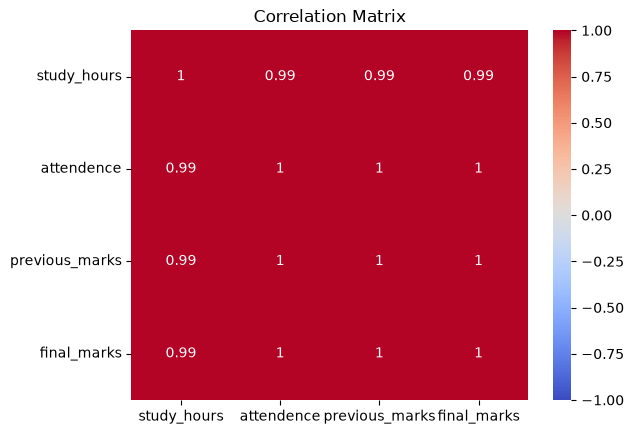

In [25]:
correlation_matrix = data.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix")
plt.show()


In [27]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
X=data.data
y=data.target

#Chi square required non negative feature values
X_non_negative = MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func=chi2,k=5)
X_selected = selector.fit_transform(X_non_negative,y)

selected_features = data.feature_names[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.datasets import load_iris

iris = load_iris()
X,y = iris.data,iris.target

X_select = SelectKBest(chi2,k=1).fit_transform(X,y)
X_select

In [36]:
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

iris = load_iris()
X,y = iris.data,iris.target

selector = SelectKBest(score_func=f_classif,k=2)
X_select = selector.fit_transform(X,y)

selected_features = np.array(iris.feature_names)[selector.get_support()]
print("Seleced Features:",selected_features)



Seleced Features: ['petal length (cm)' 'petal width (cm)']


In [40]:
import io
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.read_csv("data/data-1.csv")
selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

print("Selected Features:", list(selected_columns))

Selected Features: ['Age', 'items']


In [41]:
import io
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.read_csv("data/data-2.csv")
selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

print("Selected Features:", list(selected_columns))

Selected Features: ['referred', 'repeat', 'Age', 'Promoted', 'items']
